# Notebook 01 — Exploratory Data Analysis (EDA)
## Statistical Audit: "pandas-dev/pandas"

---

### Informasi Anggota

| Atribut | Detail |
|---|---|
| **Nama** | [Darren Chandra Wijaya] |
| **Peran** | Data Engineer (Member A) |
| **Tanggung Jawab** | Data collection, cleaning, EDA, variable selection |

---

### Research Questions yang Dibahas di Notebook Ini

Notebook ini adalah **lapisan pertama (Layer 1)** dari pipeline analisis statistik.
Semua data yang dikumpulkan dan dibersihkan di sini akan langsung digunakan oleh
Member B, C, D, dan E di notebook berikutnya.

| # | Research Question | Fokus EDA di Notebook Ini |
|---|---|---|
| **RQ1** | Berapa probabilitas estimasi sebuah Pull Request (PR) di "pandas-dev/pandas" akan di-merge, dan seberapa tidak pasti estimasi tersebut? | Mengidentifikasi nilai `k` (merged) dan `m` (rejected) sebagai input **MLE Bernoulli** & **Beta posterior** |
| **RQ2** | Apakah rata-rata tingkat laporan bug per bulan mengalami perubahan yang signifikan secara statistik setelah rilis Pandas 2.0 (April 2023)? | Menghitung `bug_count` per bulan, dipisah pre/post v2.0, sebagai input **MLE Poisson** & **Z-test** |
| **RQ3** | Berapa probabilitas sebuah issue membutuhkan waktu lebih dari 30 hari untuk di-close, dan seberapa akurat sistem Bloom Filter dalam mendeteksi laporan duplikat? | Menghitung distribusi `resolution_days` sebagai input **Monte Carlo**, dan menyiapkan kolom `title` untuk **Bloom Filter** |

## AI Usage Disclosure

**Member:** [Darren Chandra Wijaya] — Data Engineer &nbsp;|&nbsp; **Tools used:** Claude (claude.ai)

| Task | Tool | Prompt summary | Output modified? |
|---|---|---|---|
| Generated API pagination loop | Claude | "Buatkan simple python loop untuk fetch API Github dengan paginasi" | Yes — ditambahkan batas "max_pages", pesan status, pesan diagnostik dan jeda "time.sleep(1)" |
| Membuat Logic fetching dan Cleaning Issues | Claude | "Buatkan logic untuk fetching dan cleaning issues yang mengambil data per bulan" | Yes — diubah menggunakan Github Search API, iterasi rentang waktu dengan pd.date_range, jeda time.sleep(4), serta penggabungan dan deduplikasi dengan dictionary, dan ditambahkan counter diagnostik |
| Template subplot 1×2 dan 2×1 untuk visualisasi | Claude | "Buatkan template subplot matplotlib untuk visualisasi EDA yang informatif dan rapi" | Yes — disesuaikan warna, label, anotasi angka, dan judul berdasarkan data aktual |
| Template kerangka markdown | Claude | "Buatkan template kerangka markdown yang baik dan rapih" | Yes — isi nya ditulis sendiri |

**Written entirely without AI:** Semua sel interpretasi/markdown termasuk analisis temuan EDA, penjelasan implikasi statistik, dan sel ringkasan handoff.

In [1]:
# Library
import requests
import pandas as pd
import numpy as np
import time
import json
import os
import getpass
import matplotlib.pyplot as plt
import seaborn as sns

# Setup Folder
os.makedirs("../data/raw", exist_ok=True)
os.makedirs("../data/clean", exist_ok=True)
os.makedirs("../report", exist_ok=True)

# Settingan Visual untuk Plot 
sns.set_theme(style="whitegrid")
plt.rcParams["figure.dpi"] = 100

print("Semua library berhasil diimpor.")

Semua library berhasil diimpor.


In [2]:
# 1. Konfigurasi Github Token dan Target Repo
# Konfigurasi Input Token 
print("Masukkan GitHub Personal Access Token Anda:")
GITHUB_TOKEN = getpass.getpass()

# Konfigurasi target repo
REPO = "pandas-dev/pandas"
HEADERS = {"Authorization": f"token {GITHUB_TOKEN}"}

print("\n Konfigurasi selesai.")
print(f"  Target repo : {REPO}")
print(f"  Token       : {'*' * 20}")

Masukkan GitHub Personal Access Token Anda:

 Konfigurasi selesai.
  Target repo : pandas-dev/pandas
  Token       : ********************


### Penjelasan Setup

Kita menggunakan **GitHub REST API** untuk mengambil data langsung dari repositori
"pandas-dev/pandas". Repositori ini dipilih karena:
Memiliki ribuan pull request dan issues closed yang cukup untuk analisis statistik yang robust
Data terlabel dengan baik, termasuk label "bug" yang kita butuhkan untuk RQ2
Riwayat panjang (sejak 2011) sehingga ada data yang mencakup periode pre dan post Pandas 2.0 (April 2023)

**Kenapa perlu GitHub Token?**
Tanpa token: batas 60 request/jam
Dengan token: batas 5.000 request/jam

> **Catatan Keamanan:** Kita menggunakan "getpass.getpass()" agar token diinput secara tersembunyi
> dan tidak masuk ke riwayat notebook.

In [3]:
# 2. Data Fetching dari Github API untuk PR dan Issues
# A. Fetch Pull Requests (RQ1)
def fetch_github_data(endpoint, params, max_pages=20):
    all_data = []
    url = f"https://api.github.com/repos/{REPO}/{endpoint}"
    print(f"Mengambil data dari endpoint: /{endpoint}")
    
    for page in range(1, max_pages + 1):
        params["page"] = page
        params["per_page"] = 100
        
        response = requests.get(url, headers=HEADERS, params=params)
        
        if response.status_code != 200:
            print(f"Berhenti di halaman {page}. Status code: {response.status_code}")
            break
            
        data = response.json()
        if not data:
            print(f"Semua data sudah terambil.Selesai di halaman {page - 1}.")
            break 
            
        all_data.extend(data)
        print(f"Halaman {page}: {len(data)} item  |  Total terkumpul: {len(all_data)}")
        time.sleep(1) 

    print(f"\nSelesai! Total data dari /{endpoint}: {len(all_data)} item\n")
    return all_data

pr_params = {"state": "closed", "sort": "created", "direction": "desc"}
raw_prs = fetch_github_data("pulls", pr_params, max_pages=50) 
with open("../data/raw/raw_prs.json", "w") as f: json.dump(raw_prs, f) # Simpan data mentah sebagai backup
print(f"Data berhasil disimpan ke: {"../data/raw/raw_prs.json"}")
print(f"\nTotal raw PR tersedia: {len(raw_prs)}")

# B. Fetch Issues Menggunakan Search API (RQ2 & RQ3)
def fetch_issues_by_month(start_date, end_date):
    all_data = []

    daftar_bulan = pd.date_range(start=start_date, end=end_date, freq="MS")

    for awal_bulan in daftar_bulan:
        akhir_bulan = awal_bulan + pd.offsets.MonthEnd(0)

        str_awal = awal_bulan.strftime("%Y-%m-%d")
        str_akhir = akhir_bulan.strftime("%Y-%m-%d")
        
        print(f"\n--- Mengambil data bulan: {str_awal} sampai {str_akhir} ---")

        url = "https://api.github.com/search/issues"
        query = f"repo:{REPO} is:issue is:closed created:{str_awal}..{str_akhir}"
        print(f"Mencari data: {query}")
        
        for page in range(1, 11):
            params = {"q": query, "per_page": 100, "page": page}
            response = requests.get(url, headers=HEADERS, params=params)
            
            if response.status_code != 200:
                print(f"Berhenti di halaman {page}. Status: {response.status_code}")
                break
                
            data = response.json().get("items", [])
            if not data:
                break
                
            all_data.extend(data)
            print(f"Halaman {page}: {len(data)} item terkumpul")
            time.sleep(4)  
        
    return all_data

print("Fetch PRE Pandas v2.0 issues...")
raw_pre_iss = fetch_issues_by_month("2021-01-01", "2023-04-02")
print("\nFetch POST Pandas v2.0 issues...")
raw_post_iss = fetch_issues_by_month("2023-04-03", "2025-12-31")

combined_dict = {i["number"]: i for i in raw_pre_iss + raw_post_iss}
raw_issues = list(combined_dict.values())

with open("../data/raw/raw_issues.json", "w") as f:json.dump(raw_issues, f)

print(f"\nPRE Pandas 2.0   : {len(raw_pre_iss)} issues")
print(f"POST Pandas 2.0    : {len(raw_post_iss)} issues")
print(f"Total unik         : {len(raw_issues)} issues")

print(f"\nSelesai! Total PR: {len(raw_prs)} | Total Issue: {len(raw_issues)}")

Mengambil data dari endpoint: /pulls
Halaman 1: 100 item  |  Total terkumpul: 100
Halaman 2: 100 item  |  Total terkumpul: 200
Halaman 3: 100 item  |  Total terkumpul: 300
Halaman 4: 100 item  |  Total terkumpul: 400
Halaman 5: 100 item  |  Total terkumpul: 500
Halaman 6: 100 item  |  Total terkumpul: 600
Halaman 7: 100 item  |  Total terkumpul: 700
Halaman 8: 100 item  |  Total terkumpul: 800
Halaman 9: 100 item  |  Total terkumpul: 900
Halaman 10: 100 item  |  Total terkumpul: 1000
Halaman 11: 100 item  |  Total terkumpul: 1100
Halaman 12: 100 item  |  Total terkumpul: 1200
Halaman 13: 100 item  |  Total terkumpul: 1300
Halaman 14: 100 item  |  Total terkumpul: 1400
Halaman 15: 100 item  |  Total terkumpul: 1500
Halaman 16: 100 item  |  Total terkumpul: 1600
Halaman 17: 100 item  |  Total terkumpul: 1700
Halaman 18: 100 item  |  Total terkumpul: 1800
Halaman 19: 100 item  |  Total terkumpul: 1900
Halaman 20: 100 item  |  Total terkumpul: 2000
Halaman 21: 100 item  |  Total terkumpul:

### Interpretasi: Hasil Pengambilan Data

Kita berhasil mengumpulkan dua dataset mentah dari GitHub API:

**1. Pull Request ("raw_prs.json") — untuk RQ1**
Diambil dari endpoint /pulls dengan parameter state=closed, sort=created, dan direction=desc.
Berisi semua PR yang sudah ditutup, baik yang di-*merge* (diterima) maupun yang di-*close* tanpa
di-*merge* (ditolak). Ini adalah data utama untuk menghitung probabilitas merge PR.

**2. Issues ("raw_issues.json") — untuk RQ2 dan RQ3**
Diambil menggunakan GitHub Search API (/search/issues) daripada endpoint issues biasa.
Pengambilan dilakukan secara iteratif per bulan menggunakan pd.date_range untuk mengakali batasan maksimal 1.000 hasil dari Search API GitHub. Data diambil dalam dua periode untuk mencakup masa sebelum dan sesudah rilis Pandas 2.0 (April 2023):
PRE Pandas 2.0: 1 Januari 2021 – 2 April 2023
POST Pandas 2.0: 3 April 2023 – 31 Desember 2025
> **Penting:** Karena kita menggunakan parameter pencarian is:issue pada kueri API, hasil yang ditarik murni hanya Issues. Pull Request sudah disaring sejak awal dari sisi server GitHub. Data ini kemudian digabungkan dan dideduplikasi berdasarkan nomor seri issue

**Sistem Cache Lokal:**
Setelah proses fetching selesai, masing-masing data langsung disimpan ke penyimpanan lokal di dalam direktori ../data/raw/ dengan format JSON (raw_prs.json dan raw_issues.json). File ini berfungsi sebagai backup data mentah (raw data) yang siap dibaca dari disk pada tahap cleaning selanjutnya.

In [4]:
# 3. Data Cleaning untuk PR
PANDAS_V2_DATE = pd.Timestamp("2023-04-03")

pr_list = []
jumlah_draft_dilewati = 0
jumlah_tanpa_closed = 0
jumlah_anomali = 0
jumlah_diluar_range = 0

for pr in raw_prs:
    if pr.get("draft") == True: 
        jumlah_draft_dilewati += 1
        continue 
    
    created = pd.Timestamp(pr["created_at"])
    start_bound = pd.Timestamp("2021-01-01", tz="UTC")
    end_bound = pd.Timestamp("2025-12-31 23:59:59", tz="UTC")
    
    if not (start_bound <= created <= end_bound):
        jumlah_diluar_range += 1
        continue

    closed_at = pr.get("closed_at")
    merged_at = pr.get("merged_at")
    
    if closed_at is None:
        jumlah_tanpa_closed += 1
        continue

    closed = pd.Timestamp(closed_at)
    days   = (closed - created).total_seconds() / 86400

    if days <= 0:
        jumlah_anomali += 1
        continue

    is_merged = True if merged_at else False

    pr_list.append({
        "number"         : pr["number"],
        "created_at"     : created,
        "merged"         : is_merged,
        "outcome"        : 1 if is_merged else 0,  
        "resolution_days": round(days, 2)
    })

df_prs = pd.DataFrame(pr_list)

print("HASIL CLEANING DATA PULL REQUEST")
print(f"Raw PR masuk              : {len(raw_prs)}")
print(f"Draft PR dilewati         : {jumlah_draft_dilewati}")
print(f"PR tanpa closed_at        : {jumlah_tanpa_closed}")
print(f"Data anomali (days <= 0)  : {jumlah_anomali}")
print(f"Di luar rentang tanggal   : {jumlah_diluar_range}")
print(f"───────────────────────────────")
print(f"PR valid (df_prs)         : {len(df_prs)}")
print(f"PR Merged   (k)           : {df_prs['merged'].sum()}")
print(f"PR Rejected (m)           : {(~df_prs['merged']).sum()}")
print()
df_prs.head()

HASIL CLEANING DATA PULL REQUEST
Raw PR masuk              : 5000
Draft PR dilewati         : 168
PR tanpa closed_at        : 0
Data anomali (days <= 0)  : 0
Di luar rentang tanggal   : 1604
───────────────────────────────
PR valid (df_prs)         : 3228
PR Merged   (k)           : 2287
PR Rejected (m)           : 941



,number,created_at,merged,outcome,resolution_days
0,63525,2025-12-31 21:19:12+00:00,True,1,0.93
1,63524,2025-12-31 19:57:20+00:00,False,0,29.94
2,63523,2025-12-31 17:26:51+00:00,True,1,0.08
3,63522,2025-12-31 16:39:28+00:00,True,1,1.12
4,63520,2025-12-31 06:37:27+00:00,True,1,1.53


### Interpretasi: Cleaning Data Pull Request

Dari data PR mentah, kita melakukan **empat langkah penyaringan**:
1. **Skip PR Draft** PR berstatus *draft* belum diajukan untuk review resmi, sehingga
   tidak ada outcome merge/reject yang bermakna secara statistik.
2. **Skip PR tanpa "closed_at"** Jika "closed_at" kosong, PR masih open dan belum ada
   outcome final-nya. Tidak bisa dimasukkan ke analisis Bernoulli.
3. **Skip "resolution_days ≤ 0"** Membuang data anomali akibat kemungkinan kesalahan
   pencatatan timestamp.
4. **Filter Rentang Waktu** Hanya menyertakan PR yang dibuat (created_at) dalam rentang 1 Januari 2021 hingga 31 Desember 2025. Ini menyelaraskan data PR dengan periode pengambilan data Issues (PRE dan POST Pandas 2.0).

**Kolom kunci yang dihasilkan:**

| Kolom | Tipe | Keterangan |
|---|---|---|
| "number" | int | Nomor seri unik identifikasi Pull Request |
| "merged" | bool | True/False untuk filter dan visualisasi |
| "resolution_days" | float | Berapa hari PR diselesaikan |
| "created_at" | datetime | Waktu PR dibuat (digunakan untuk memisahkan era PRE/POST) |
| "outcome" | int | 1 = merged, 0 = rejected untuk variabel Bernoulli |

> **Nilai yang diteruskan ke Member B:**
> "k" = jumlah PR merged (baris di mana "outcome == 1")
> "m" = jumlah PR rejected (baris di mana "outcome == 0")
> "n = k + m" = total PR valid
>
> Member B akan menggunakan ini untuk **MLE Bernoulli** ("θ̂ = k/n")
> dan **Beta posterior** ("α = k + 1", "β = m + 1"  bukan "k" dan "m" langsung)

In [5]:
# 4. Data Cleaning untuk Issues
issue_list = []
jumlah_pr_dilewati  = 0
jumlah_anomali_iss  = 0
jumlah_diluar_range = 0

for issue in raw_issues:
    if "pull_request" in issue:
        jumlah_pr_dilewati += 1
        continue
    
    created = pd.Timestamp(issue["created_at"])
    start_bound = pd.Timestamp("2021-01-01", tz="UTC")
    end_bound = pd.Timestamp("2025-12-31 23:59:59", tz="UTC")
    
    if not (start_bound <= created <= end_bound):
        jumlah_diluar_range += 1
        continue

    labels = [label["name"].lower() for label in issue.get("labels", [])]
    is_bug = any("bug" in label for label in labels)
    
    closed_at = issue.get("closed_at")
    if closed_at is None: continue

    closed = pd.Timestamp(closed_at)
    days   = (closed - created).total_seconds() / 86400

    if days <= 0:
        jumlah_anomali_iss += 1
        continue

    issue_list.append({
        "number"         : issue["number"],
        "title"          : issue.get("title", ""),  
        "type"           : "bug" if is_bug else "other",
        "created_at"     : created,
        "resolution_days": round(days, 2)
    })

df_issues = pd.DataFrame(issue_list)

# Buat dataframe khusus bug per bulan untuk Poisson (RQ2)
df_issues["yearmonth"] = df_issues["created_at"].dt.to_period("M")
df_bugs = df_issues[df_issues["type"] == "bug"].copy()

issues_start = df_issues["created_at"].min()
issues_end = df_issues["created_at"].max()
full_monthly_range = pd.period_range(start=issues_start, end=issues_end, freq='M')

bugs_counted = df_bugs.groupby("yearmonth").size()

monthly_bugs_fixed = bugs_counted.reindex(full_monthly_range, fill_value=0).reset_index(name="bug_count")
monthly_bugs_fixed.rename(columns={'index': 'yearmonth'}, inplace=True) # Perbaiki nama kolom index

monthly_bugs_fixed["timestamp"] = monthly_bugs_fixed["yearmonth"].dt.to_timestamp()
monthly_bugs_fixed["period"] = monthly_bugs_fixed["timestamp"].apply(
    lambda x: "post_v2" if x >= PANDAS_V2_DATE else "pre_v2"
)

monthly_bugs = monthly_bugs_fixed.copy()

print("HASIL CLEANING DATA ISSUES")
print(f"Raw issues masuk               : {len(raw_issues)}")
print(f"PR yang dilewati               : {jumlah_pr_dilewati}")
print(f"Anomali (days <= 0)            : {jumlah_anomali_iss}")
print(f"Di luar rentang tanggal        : {jumlah_diluar_range}")
print(f"  ───────────────────────────────")
print(f"Issue valid (df_issues)        : {len(df_issues)}")
print(f"Tipe Bug                       : {len(df_bugs)}")
print(f"Tipe Lain                      : {len(df_issues) - len(df_bugs)}")
print(f"Bulan data bug (monthly_bugs)  : {len(monthly_bugs)} bulan")
print()
df_issues.head()

C:\Users\Darren CW\AppData\Local\Temp\ipykernel_41732\3024322014.py:44: UserWarning: Converting to PeriodArray/Index representation will drop timezone information.
  df_issues["yearmonth"] = df_issues["created_at"].dt.to_period("M")


HASIL CLEANING DATA ISSUES
Raw issues masuk               : 6751
PR yang dilewati               : 0
Anomali (days <= 0)            : 0
Di luar rentang tanggal        : 0
  ───────────────────────────────
Issue valid (df_issues)        : 6751
Tipe Bug                       : 3067
Tipe Lain                      : 3684
Bulan data bug (monthly_bugs)  : 60 bulan



,number,title,type,created_at,resolution_days,yearmonth
0,39514,BUG: Reading csv files with numbers with multi...,bug,2021-01-31 22:04:03+00:00,1879.84,2021-01
1,39513,TYP: Mypy failures with new numpy,other,2021-01-31 22:03:40+00:00,37.95,2021-01
2,39503,BUG: Repeated key words on datetime indexing m...,other,2021-01-31 17:30:06+00:00,0.16,2021-01
3,39489,BUG: GroupBy Aggregation Behavior,bug,2021-01-30 19:56:30+00:00,196.35,2021-01
4,39481,BUG: Stack creates duplicate column,bug,2021-01-30 15:53:12+00:00,4.42,2021-01


### Interpretasi: Cleaning Data Issues

Proses cleaning untuk data issues melibatkan langkah penyaringan yang mirip dengan PR, 
ditambah dengan beberapa penanganan khusus untuk klasifikasi dan agregasi waktu:

**Menyaring PR dari Data Issues:**
Meskipun kita menggunakan Search API, kita tetap melakukan validasi ekstra dengan mengecek field pull_request di response JSON. 
Jika field tersebut ada, berarti item tersebut adalah PR dan akan di-skip.

**Filter Rentang Waktus:**
Memastikan created_at berada dalam batasan waktu yang sama dengan PR (1 Januari 2021 hingga 31 Desember 2025).

**Skip Issue Open & Anomali:**
Sama seperti PR, kita mengabaikan issue yang belum ditutup (closed_at kosong) 
dan membuang anomali durasi waktu penyelesaian (resolution_days ≤ 0).

**Deteksi label bug:**
Filter "any("bug" in label for label in labels)" menangkap semua variasi label bug di
repositori, seperti "Bug", "type: Bug", "regression", dll. 
Berdasarkan filter ini, data dikategorikan ke dalam kolom type sebagai "bug" atau "other".

**Tiga dataset yang dihasilkan dari cleaning ini:**

| Dataset | Jumlah Baris | Digunakan untuk |
|---|---|---|
| `df_issues` | semua issue valid | RQ3: distribusi "resolution_days" & judul untuk Bloom Filter |
| `df_bugs` | subset issue berlabel bug | RQ2: sumber rangkuman per bulan |
| `monthly_bugs` | rangkuman total bug per bulan | RQ2: input langsung MLE Poisson dan Z-test |

**Titik potong Pandas 2.0:**
Data pada monthly_bugs secara otomatis diberikan label period (pre_v2 atau post_v2) berdasarkan tanggal rilis Pandas 2.0 (3 April 2023). 
Pemisahan periode ini sangat kritis untuk melakukan perbandingan statistik di RQ2.

In [6]:
# 5. Simpan Dataset Bersih ke CSV
df_prs.to_csv("../data/clean/prs_clean.csv", index=False)
df_issues.to_csv("../data/clean/issues_full.csv", index=False)
monthly_bugs.to_csv("../data/clean/monthly_bugs.csv", index=False)

print("Data berhasil dibersihkan dan disimpan ke folder clean")
print(f"prs_clean.csv:{len(df_prs)} baris")
print(f"issues_full.csv:{len(df_issues)} baris")
print(f"monthly_bugs.csv:{len(monthly_bugs)} baris")

Data berhasil dibersihkan dan disimpan ke folder clean
prs_clean.csv:3228 baris
issues_full.csv:6751 baris
monthly_bugs.csv:60 baris


### Schema Dataset yang Tersimpan

Berikut penjelasan kolom dari setiap file CSV yang dihasilkan:

---

**"prs_clean.csv"** Input utama untuk **Member B** (RQ1)

| Kolom | Tipe | Keterangan |
|---|---|---|
| "number" | int | Nomor identifikasi Pull Request di GitHub |
| "created_at" | datetime | Tanggal PR dibuat |
| "merged" | bool | "True" jika di-merge, "False" jika ditolak |
| "outcome" | int | **1** = merged, **0** = rejected (variabel Bernoulli) |
| "resolution_days" | float | Berapa hari PR diselesaikan sejak dibuat |

---

**"issues_full.csv"** Input utama untuk **Member E** (RQ3)

| Kolom | Tipe | Keterangan |
|---|---|---|
| "number" | int | Nomor identifikasi Issue di GitHub |
| "title" | str | Judul issue digunakan sebagai item input di **Bloom Filter** |
| "type" | str | kategori issue: "bug" atau "other" |
| "created_at" | datetime | Tanggal issue dibuat |
| "resolution_days" | float | Berapa hari issue diselesaikan (threshold: 30 hari) |

---

**"monthly_bugs.csv"** Input utama untuk **Member B & D** (RQ2)

| Kolom | Tipe | Keterangan |
|---|---|---|
| "yearmonth" | period | Periode bulan (format YYYY-MM) |
| "bug_count" | int | Jumlah bug dilaporkan di bulan tersebut |
| "timestamp" | datetime | Tanggal awal bulan (untuk plotting) |
| "period" | str | Label era rilis: "pre_v2" atau "post_v2" (titik potong: 3 April 2023) |

In [7]:
# 6. Statistik Deskriptif
print("STATISTIK DESKRIPTIF — PULL REQUEST (df_prs)")
print(df_prs[["outcome", "resolution_days"]].describe().round(2))

print()
print("STATISTIK DESKRIPTIF — ISSUES (df_issues)")
print(df_issues[["resolution_days"]].describe().round(2))

print()
print("STATISTIK DESKRIPTIF — BUG PER BULAN (monthly_bugs)")
print(monthly_bugs[["bug_count"]].describe().round(2))

print()
print("DISTRIBUSI TIPE ISSUE")
print(df_issues["type"].value_counts().to_string())

STATISTIK DESKRIPTIF — PULL REQUEST (df_prs)
       outcome  resolution_days
count  3228.00          3228.00
mean      0.71            16.09
std       0.45            42.02
min       0.00             0.00
25%       0.00             0.20
50%       1.00             1.17
75%       1.00             9.80
max       1.00           582.57

STATISTIK DESKRIPTIF — ISSUES (df_issues)
       resolution_days
count          6751.00
mean            162.43
std             328.69
min               0.00
25%               1.13
50%              12.54
75%             135.15
max            1942.94

STATISTIK DESKRIPTIF — BUG PER BULAN (monthly_bugs)
       bug_count
count      60.00
mean       51.12
std        18.69
min        20.00
25%        32.75
50%        52.00
75%        66.00
max        86.00

DISTRIBUSI TIPE ISSUE
type
other    3684
bug      3067


### Interpretasi: Statistik Deskriptif

Sebelum masuk ke visualisasi per research question, statistik deskriptif memberikan
gambaran awal tentang karakteristik data:

**Dataset Pull Request ("df_prs"):**
Kolom "outcome" (bernilai 0 atau 1) dengan nilai rata-rata (mean) mencerminkan
proporsi kasar PR yang di-merge. Jika mean mendekati 0.7, artinya ~70% PR berhasil di-merge.
Kolom "resolution_days" kemungkinan memiliki distribusi **right-skewed** (nilai max
jauh lebih besar dari median), karena ada PR yang menunggu lama sebelum di-review.

**Dataset Issues ("df_issues"):**
Distribusi "resolution_days" juga cenderung right-skewed. Mayoritas issue diselesaikan
cepat, namun ada yang tertunda berminggu-minggu atau berbulan-bulan.
Perbedaan antara median dan mean yang besar adalah tanda klasik distribusi skewed.

**Dataset Bug per Bulan ("monthly_bugs"):**
Kolom "bug_count" adalah nilai yang akan dimodelkan dengan **distribusi Poisson** (RQ2),
di mana kita mengasumsikan bug datang dengan laju λ yang konstan dalam setiap periode.
Nilai mean dari "bug_count" adalah **estimasi awal λ̂** yang akan diformalkan oleh Member B.

> Ketiga dataset ini siap untuk dianalisis lebih lanjut di Notebook 02 (Estimasi),
> 03 (CI), 04 (Hypothesis Testing), dan 05 (Simulasi).

RQ1: OUTCOME PULL REQUEST
Total PR (n)       : 3228
PR Merged (k)      : 2287
PR Rejected (m)    : 941
Preview θ̂ = k/n    : 0.7085



C:\Users\Darren CW\AppData\Local\Temp\ipykernel_41732\2441140947.py:19: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(
C:\Users\Darren CW\AppData\Local\Temp\ipykernel_41732\2441140947.py:28: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[0].set_xticklabels(["Rejected (0)", "Merged (1)"])


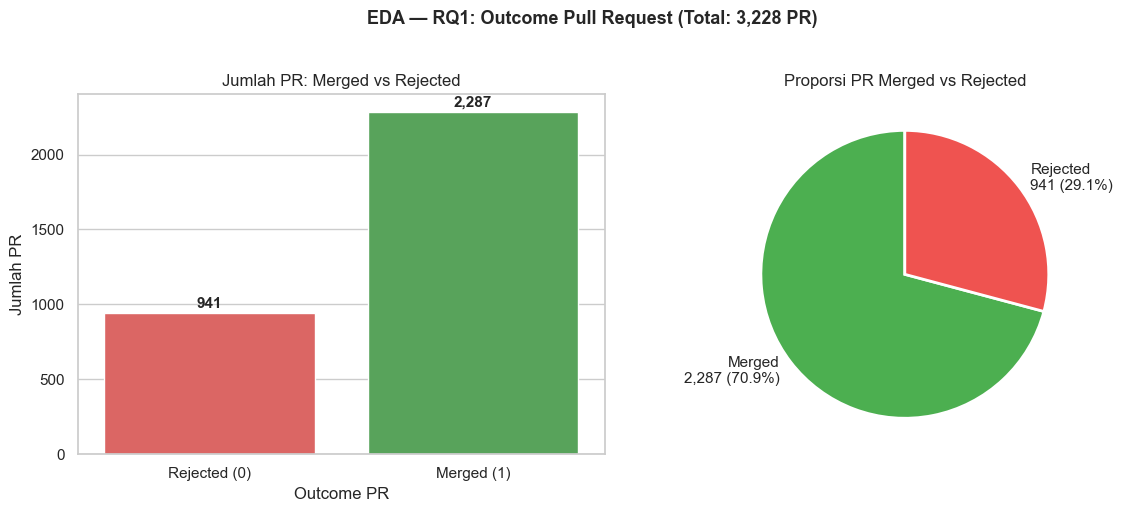

In [8]:
# 7. EDA RQ1: Proporsi PR MERGED vs REJECTED

# Hitung variabel kunci untuk RQ1
k = int(df_prs["merged"].sum())       
m = int((~df_prs["merged"]).sum())    
n = len(df_prs)                       
theta_preview = round(k / n, 4)       

print("RQ1: OUTCOME PULL REQUEST")
print(f"Total PR (n)       : {n}")
print(f"PR Merged (k)      : {k}")
print(f"PR Rejected (m)    : {m}")
print(f"Preview θ̂ = k/n    : {theta_preview}")
print()

# Visualitation RQ1
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

sns.countplot(
    data=df_prs,
    x="merged",
    palette={"False":"#EF5350", "True":"#4CAF50"},
    ax=axes[0]
)
axes[0].set_title("Jumlah PR: Merged vs Rejected", fontsize=12)
axes[0].set_xlabel("Outcome PR")
axes[0].set_ylabel("Jumlah PR")
axes[0].set_xticklabels(["Rejected (0)", "Merged (1)"])

for bar in axes[0].patches:
    height = int(bar.get_height())
    axes[0].text(
        bar.get_x() + bar.get_width() / 2,
        height + max(n * 0.005, 3),
        f"{height:,}",
        ha="center", va="bottom",
        fontsize=11, fontweight="bold"
    )

pie_labels = [
    f"Merged\n{k:,} ({theta_preview * 100:.1f}%)",
    f"Rejected\n{m:,} ({(1 - theta_preview) * 100:.1f}%)"
]
axes[1].pie(
    [k, m],
    labels=pie_labels,
    colors=["#4CAF50", "#EF5350"],
    startangle=90,
    wedgeprops={"edgecolor": "white", "linewidth": 2}
)
axes[1].set_title("Proporsi PR Merged vs Rejected", fontsize=12)

plt.suptitle(
    f"EDA — RQ1: Outcome Pull Request (Total: {n:,} PR)",
    fontsize=13, fontweight="bold", y=1.02
)
plt.tight_layout()
plt.show()

### Interpretasi RQ1: Probabilitas PR Di-Merge

Dari visualisasi di atas, terlihat bahwa **mayoritas PR di "pandas-dev/pandas" berhasil di-merge**.
Ini adalah temuan awal yang penting sebelum estimasi formal dilakukan.

**Apa yang ditunjukkan bar chart dan pie chart:**
Bar chart memberikan gambaran absolut (jumlah PR) dari masing-masing outcome.
Pie chart memberikan gambaran proporsi relatif, yang secara visual merepresentasikan
probabilitas empiris sebuah PR akan di-merge.
Nilai θ̂ preview (yang tercetak di output kode) adalah estimasi awal menggunakan
rumus sederhana "k / n". Ini adalah hasil **MLE Bernoulli** yang akan diformalkan
secara matematis oleh Member B.

**Implikasi untuk analisis berikutnya:**
**Member B** akan menggunakan "k" dan "m" untuk:
Menghitung **MLE Bernoulli** secara formal (derivasi "d ln L / dθ = 0")
Membangun **distribusi Beta posterior** dengan "α = k + 1" dan "β = m + 1"
*(bukan k dan m secara langsung sesuai Tsun 2020, p. 269)*
**Member C** akan menggunakan θ̂ untuk menghitung **Confidence Interval**
dari estimasi probabilitas merge.

> **Nilai kunci yang diteruskan ke Member B:** "k", "m", "n", dan file "prs_clean.csv"

RQ2: TREN BUG REPORT PRE vs POST PANDAS 2.0
Bulan data Pre  Pandas 2.0  : 28 bulan
Bulan data Post Pandas 2.0  : 32 bulan
Preview λ̂₁ (pre  v2.0)      : 61.3929 bug/bulan
Preview λ̂₂ (post v2.0)      : 42.125 bug/bulan
Selisih rata-rata           : 19.2679 bug/bulan



C:\Users\Darren CW\AppData\Local\Temp\ipykernel_41732\3124241134.py:49: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


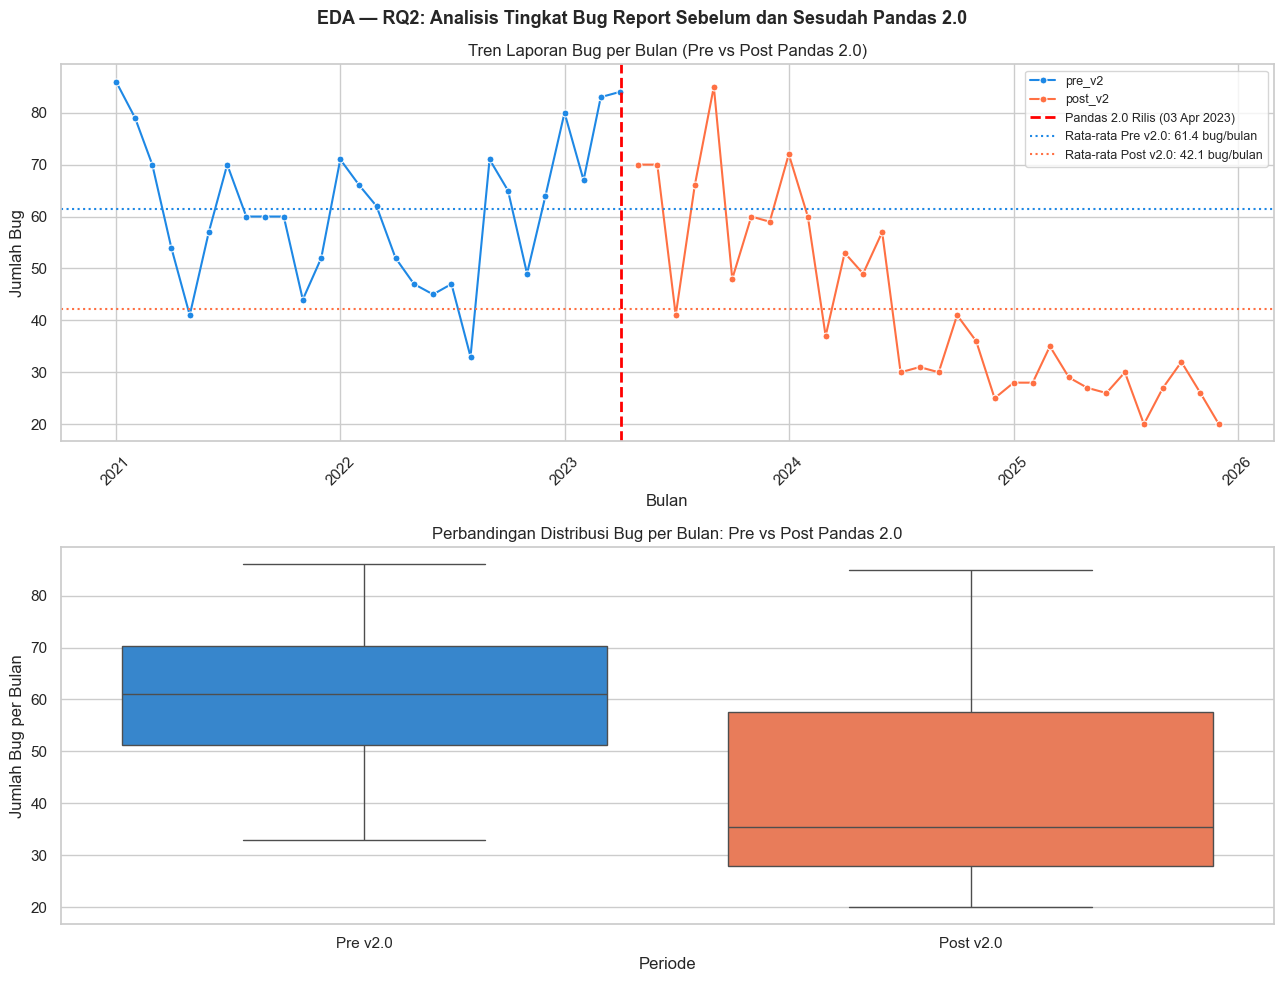

In [9]:
# 8. EDA RQ2: Report Jumlah Bug Pre vs Post Pandas v2.0
pre_data = monthly_bugs[monthly_bugs["period"] == "pre_v2"]["bug_count"]
post_data = monthly_bugs[monthly_bugs["period"] == "post_v2"]["bug_count"]

lam_pre = round(pre_data.mean(), 4)   
lam_post = round(post_data.mean(), 4)  

print("RQ2: TREN BUG REPORT PRE vs POST PANDAS 2.0")
print(f"Bulan data Pre  Pandas 2.0  : {len(pre_data)} bulan")
print(f"Bulan data Post Pandas 2.0  : {len(post_data)} bulan")
print(f"Preview λ̂₁ (pre  v2.0)      : {lam_pre} bug/bulan")
print(f"Preview λ̂₂ (post v2.0)      : {lam_post} bug/bulan")
print(f"Selisih rata-rata           : {abs(lam_post - lam_pre):.4f} bug/bulan")
print()

# Visualitation RQ2
fig, axes = plt.subplots(2, 1, figsize=(13, 10))

sns.lineplot(
    data=monthly_bugs,
    x="timestamp", y="bug_count",
    hue="period",
    palette={"pre_v2": "#1E88E5", "post_v2": "#FF7043"},
    marker="o", markersize=5,
    ax=axes[0]
)
axes[0].axvline(
    x=PANDAS_V2_DATE, color="red", linestyle="--", linewidth=2,
    label=f"Pandas 2.0 Rilis ({PANDAS_V2_DATE.strftime('%d %b %Y')})"
)
axes[0].axhline(
    y=lam_pre, color="#1E88E5", linestyle=":", linewidth=1.5,
    label=f"Rata-rata Pre v2.0: {lam_pre:.1f} bug/bulan"
)
axes[0].axhline(
    y=lam_post, color="#FF7043", linestyle=":", linewidth=1.5,
    label=f"Rata-rata Post v2.0: {lam_post:.1f} bug/bulan"
)
axes[0].set_title("Tren Laporan Bug per Bulan (Pre vs Post Pandas 2.0)", fontsize=12)
axes[0].set_xlabel("Bulan")
axes[0].set_ylabel("Jumlah Bug")
axes[0].tick_params(axis="x", rotation=45)
axes[0].legend(fontsize=9)

plot_box = pd.DataFrame({
    "Bug Count": list(pre_data) + list(post_data),
    "Periode"  : ["Pre v2.0"] * len(pre_data) + ["Post v2.0"] * len(post_data)
})
sns.boxplot(
    data=plot_box,
    x="Periode", y="Bug Count",
    palette={"Pre v2.0": "#1E88E5", "Post v2.0": "#FF7043"},
    ax=axes[1]
)
axes[1].set_title("Perbandingan Distribusi Bug per Bulan: Pre vs Post Pandas 2.0", fontsize=12)
axes[1].set_xlabel("Periode")
axes[1].set_ylabel("Jumlah Bug per Bulan")

plt.suptitle(
    "EDA — RQ2: Analisis Tingkat Bug Report Sebelum dan Sesudah Pandas 2.0",
    fontsize=13, fontweight="bold"
)
plt.tight_layout()
plt.show()


### Interpretasi RQ2: Perubahan Tingkat Bug Report Setelah Pandas 2.0

Dari kedua grafik di atas, kita dapat mengamati pola tren laporan bug per bulan
sebelum dan sesudah rilis Pandas 2.0 (3 April 2023).

**Interpretasi line chart (tren per bulan):**
Garis putus-putus merah menandai titik rilis Pandas 2.0. Kita bisa melihat secara
visual apakah ada perubahan pola setelah tanggal ini.
Garis horizontal putus-putus biru dan oranye menunjukkan **rata-rata per periode**
(preview nilai λ̂₁ dan λ̂₂). Jika kedua garis ini jauh berselisih, ada indikasi
perubahan laju bug yang perlu diuji secara statistik.
Fluktuasi tinggi di periode tertentu bisa mencerminkan siklus rilis minor atau
migrasi pengguna ke versi baru.

**Interpretasi boxplot (distribusi per periode):**
Boxplot memperlihatkan perbedaan median, kuartil, dan outlier antara dua periode.
Jika boxplot "Post v2.0" secara visual berbeda dari "Pre v2.0", ini mendukung
dugaan awal bahwa ada perubahan tingkat laporan bug.

**Catatan penting untuk batas EDA:**
EDA hanya menunjukkan *ada tidaknya perbedaan* rata-rata secara deskriptif.
Apakah perbedaan itu *signifikan secara statistik* adalah pertanyaan yang akan
dijawab oleh **Member D** di Notebook 04 (Hypothesis Testing) menggunakan Z-test.

> **Nilai kunci yang diteruskan ke Member B & D:**
> "λ̂₁" (pre-v2.0), "λ̂₂" (post-v2.0), dan file "monthly_bugs.csv"

RQ3: WAKTU PENYELESAIAN ISSUE
Total issue                   : 6,751
Issue diselesaikan > 30 hari  : 2,754
Issue diselesaikan ≤ 30 hari  : 3,997
P_empiris(X > 30 hari)        : 2754/6751 = 0.4079



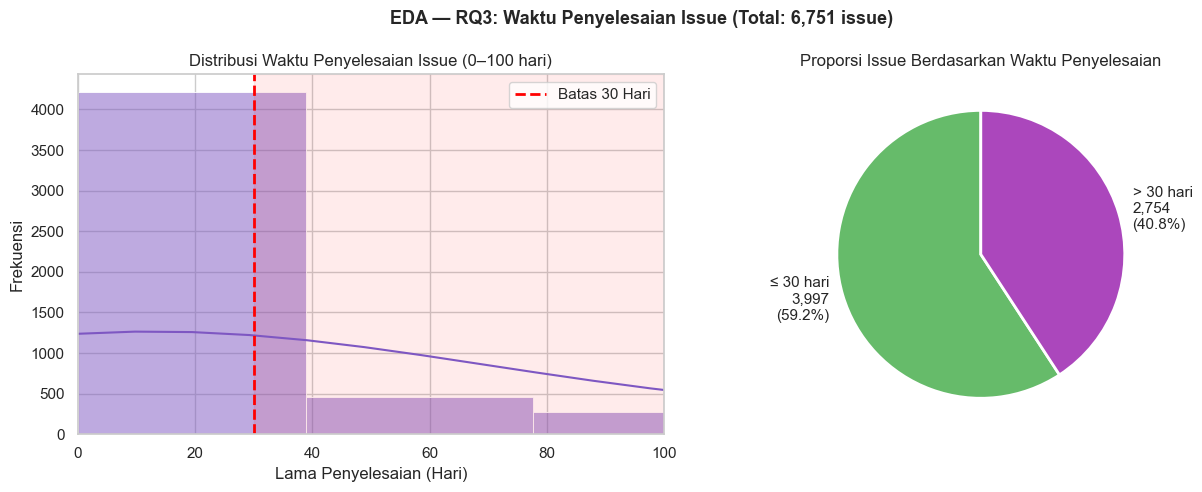

In [10]:
# 9. EDA RQ3: Distribusi Waktu Penyelesaian Issue
lebih_dari_30  = int((df_issues["resolution_days"] > 30).sum())
kurang_dari_30 = int((df_issues["resolution_days"] <= 30).sum())
total_issue    = len(df_issues)
prob_empiris   = round(lebih_dari_30 / total_issue, 4)


print("RQ3: WAKTU PENYELESAIAN ISSUE")

print(f"Total issue                   : {total_issue:,}")
print(f"Issue diselesaikan > 30 hari  : {lebih_dari_30:,}")
print(f"Issue diselesaikan ≤ 30 hari  : {kurang_dari_30:,}")
print(f"P_empiris(X > 30 hari)        : {lebih_dari_30}/{total_issue} = {prob_empiris}")
print()

#Visualitation
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

sns.histplot(
    df_issues["resolution_days"],
    bins=50, kde=True,
    color="#7E57C2",
    ax=axes[0]
)
axes[0].axvline(30, color="red", linestyle="--", linewidth=2, label="Batas 30 Hari")
axes[0].axvspan(30, 100, alpha=0.08, color="red")
axes[0].set_xlim(0, 100)
axes[0].set_title("Distribusi Waktu Penyelesaian Issue (0–100 hari)", fontsize=12)
axes[0].set_xlabel("Lama Penyelesaian (Hari)")
axes[0].set_ylabel("Frekuensi")
axes[0].legend()

pie_labels_rq3 = [
    f"≤ 30 hari\n{kurang_dari_30:,}\n({(1 - prob_empiris) * 100:.1f}%)",
    f"> 30 hari\n{lebih_dari_30:,}\n({prob_empiris * 100:.1f}%)"
]
axes[1].pie(
    [kurang_dari_30, lebih_dari_30],
    labels=pie_labels_rq3,
    colors=["#66BB6A", "#AB47BC"],
    startangle=90,
    wedgeprops={"edgecolor": "white", "linewidth": 2}
)
axes[1].set_title("Proporsi Issue Berdasarkan Waktu Penyelesaian", fontsize=12)

plt.suptitle(
    f"EDA — RQ3: Waktu Penyelesaian Issue (Total: {total_issue:,} issue)",
    fontsize=13, fontweight="bold"
)
plt.tight_layout()
plt.show()

### Interpretasi RQ3: Waktu Penyelesaian Issue dan Bloom Filter

Dari histogram dan pie chart di atas, kita mendapatkan gambaran distribusi waktu
penyelesaian issue di "pandas-dev/pandas".

**Interpretasi histogram:**
Distribusi "resolution_days" sangat **right-skewed** — ada ekor panjang ke kanan.
Mayoritas issue diselesaikan dalam waktu singkat (< 30 hari), ditunjukkan oleh
puncak histogram yang berada jauh di sisi kiri garis merah.
Kurva KDE (garis gelap di atas batang) memperjelas bentuk distribusi secara halus.
Area merah semi-transparan di sebelah kanan garis 30 hari merepresentasikan
proporsi issue yang membutuhkan waktu lebih lama dari threshold.

**Interpretasi pie chart:**
Pie chart memberikan gambaran proporsional yang lebih langsung tentang berapa
persen issue yang melewati batas 30 hari.

**Implikasi untuk analisis berikutnya:**
Nilai probabilitas empiris "P(X > 30)" adalah **titik awal** analisis.
Nilai yang lebih akurat (dan memiliki *uncertainty*) akan dihitung oleh **Member E**
menggunakan **simulasi Monte Carlo** dengan "n_trials = 50.000".
Kolom "title" di "issues_full.csv" akan digunakan oleh **Member E** untuk
membangun **Bloom Filter** — menambahkan setiap judul issue ke struktur data
probabilistik tersebut, lalu menghitung *theoretical false positive rate* (FPR)
menggunakan formula: "FPR = (1 - (1 - 1/m)^n)^k" *(Tsun 2020, p. 329)*.

> **Nilai kunci yang diteruskan ke Member E:**
> Kolom "resolution_days" dan "title" dari file "issues_full.csv",
> dengan threshold 30 hari untuk Monte Carlo.